In [57]:
import pandas as pd
import torch
import matplotlib.pyplot as plt 

In [58]:
df = pd.read_csv("01-study_hours_grades.csv")
df.head()

,study_hours,grade
0,3.745401,30.203939
1,9.507143,57.878452
2,7.319939,46.368401
3,5.986585,39.330717
4,1.560186,14.843888


In [59]:
df.info() # 50 tane non-null değer 2 column içinde.

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   study_hours  50 non-null     float64
 1   grade        50 non-null     float64
dtypes: float64(2)
memory usage: 932.0 bytes


### Deep-Learning-Training-steps
* Prepare data
* Build a model
* Prediction with model
* Evaluate with test data
* Improvement if necessary
* Save the model

In [60]:
df.describe()

,study_hours,grade
count,50.000000,50.000000
mean,4.459239,32.290305
std,2.888832,14.431931
min,0.205845,11.032281
25%,1.837670,21.062901
50%,4.360488,31.231858
75%,6.498549,41.683170
max,9.699099,60.573564


In [61]:
df['study_hours'].values

array([3.74540119, 9.50714306, 7.31993942, 5.98658484, 1.5601864 ,
       1.5599452 , 0.58083612, 8.66176146, 6.01115012, 7.08072578,
       0.20584494, 9.69909852, 8.32442641, 2.12339111, 1.81824967,
       1.8340451 , 3.04242243, 5.24756432, 4.31945019, 2.9122914 ,
       6.11852895, 1.39493861, 2.92144649, 3.66361843, 4.56069984,
       7.85175961, 1.99673782, 5.14234438, 5.92414569, 0.46450413,
       6.07544852, 1.70524124, 0.65051593, 9.48885537, 9.65632033,
       8.08397348, 3.04613769, 0.97672114, 6.84233027, 4.40152494,
       1.22038235, 4.9517691 , 0.34388521, 9.09320402, 2.58779982,
       6.62522284, 3.11711076, 5.20068021, 5.46710279, 1.84854456])

In [62]:
type(df['study_hours'].values) # Önce bunu tensor formatına çevirmeliyiz

numpy.ndarray

In [63]:
torch.tensor(df['study_hours'].values)

tensor([3.7454, 9.5071, 7.3199, 5.9866, 1.5602, 1.5599, 0.5808, 8.6618, 6.0112,
        7.0807, 0.2058, 9.6991, 8.3244, 2.1234, 1.8182, 1.8340, 3.0424, 5.2476,
        4.3195, 2.9123, 6.1185, 1.3949, 2.9214, 3.6636, 4.5607, 7.8518, 1.9967,
        5.1423, 5.9241, 0.4645, 6.0754, 1.7052, 0.6505, 9.4889, 9.6563, 8.0840,
        3.0461, 0.9767, 6.8423, 4.4015, 1.2204, 4.9518, 0.3439, 9.0932, 2.5878,
        6.6252, 3.1171, 5.2007, 5.4671, 1.8485], dtype=torch.float64)

In [64]:
# grade -> dependent variable (sonucu study_hours'a bağlı)
# study_hours -> independent variable
# bağımlı değişkenleri y ile gösteririz genelde.
y = torch.tensor(df['grade'].values)
X = torch.tensor(df['study_hours'].values)

In [65]:
y

tensor([30.2039, 57.8785, 46.3684, 39.3307, 14.8439, 16.3600, 11.9829, 55.4231,
        40.7430, 41.8775, 11.6774, 57.7253, 50.2683, 21.8403, 21.1532, 21.0328,
        23.5337, 35.6194, 32.2598, 26.5125, 39.6343, 16.6034, 22.3946, 25.9257,
        34.4286, 51.9713, 19.8397, 37.7188, 40.3440, 11.0323, 41.1000, 21.6023,
        13.1809, 60.5736, 53.0421, 52.0637, 25.4048, 14.2856, 44.3952, 28.0325,
        15.6626, 35.4731, 14.6752, 54.4295, 21.3220, 42.1226, 27.4164, 36.6609,
        36.2760, 20.2693], dtype=torch.float64)

In [66]:
X

tensor([3.7454, 9.5071, 7.3199, 5.9866, 1.5602, 1.5599, 0.5808, 8.6618, 6.0112,
        7.0807, 0.2058, 9.6991, 8.3244, 2.1234, 1.8182, 1.8340, 3.0424, 5.2476,
        4.3195, 2.9123, 6.1185, 1.3949, 2.9214, 3.6636, 4.5607, 7.8518, 1.9967,
        5.1423, 5.9241, 0.4645, 6.0754, 1.7052, 0.6505, 9.4889, 9.6563, 8.0840,
        3.0461, 0.9767, 6.8423, 4.4015, 1.2204, 4.9518, 0.3439, 9.0932, 2.5878,
        6.6252, 3.1171, 5.2007, 5.4671, 1.8485], dtype=torch.float64)

In [67]:
# train - test split
# sckitlearn kütüphanesiyle de yapabiliriz ama burada manuel yapacağız
train_split = int(len(X) * 0.8) # Yani X data uzunluğunun %80'i alacağız train için
X_train, y_train = X[:train_split], y[:train_split] # X ve y'nin ilk 40'ını alıyoruz. 
X_test, y_test = X[train_split:], y[train_split:] # ilk 40'ını alma sonrasını al. Test için
# Tabii ki böyle almak en doğru yaklaşım değil veriler sıralı vs olabilir. Karıştırıp alabiliriz.
# Şu an için sadece örnek olması adına karıştırmıyoruz.

In [68]:
X_train

tensor([3.7454, 9.5071, 7.3199, 5.9866, 1.5602, 1.5599, 0.5808, 8.6618, 6.0112,
        7.0807, 0.2058, 9.6991, 8.3244, 2.1234, 1.8182, 1.8340, 3.0424, 5.2476,
        4.3195, 2.9123, 6.1185, 1.3949, 2.9214, 3.6636, 4.5607, 7.8518, 1.9967,
        5.1423, 5.9241, 0.4645, 6.0754, 1.7052, 0.6505, 9.4889, 9.6563, 8.0840,
        3.0461, 0.9767, 6.8423, 4.4015], dtype=torch.float64)

In [69]:
X_test

tensor([1.2204, 4.9518, 0.3439, 9.0932, 2.5878, 6.6252, 3.1171, 5.2007, 5.4671,
        1.8485], dtype=torch.float64)

In [70]:
y_test

tensor([15.6626, 35.4731, 14.6752, 54.4295, 21.3220, 42.1226, 27.4164, 36.6609,
        36.2760, 20.2693], dtype=torch.float64)

In [71]:
y_train

tensor([30.2039, 57.8785, 46.3684, 39.3307, 14.8439, 16.3600, 11.9829, 55.4231,
        40.7430, 41.8775, 11.6774, 57.7253, 50.2683, 21.8403, 21.1532, 21.0328,
        23.5337, 35.6194, 32.2598, 26.5125, 39.6343, 16.6034, 22.3946, 25.9257,
        34.4286, 51.9713, 19.8397, 37.7188, 40.3440, 11.0323, 41.1000, 21.6023,
        13.1809, 60.5736, 53.0421, 52.0637, 25.4048, 14.2856, 44.3952, 28.0325],
       dtype=torch.float64)

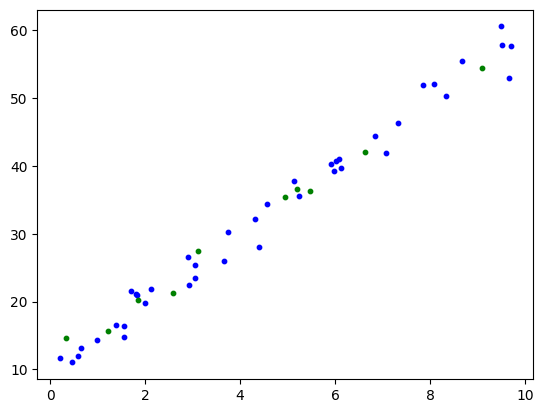

In [72]:
plt.scatter(x=X_train,y=y_train,c="b",s=10, label="Training Data") # s -> size of data points.
plt.scatter(x=X_test,y=y_test,c="g",s=10,label = "Test Data")
plt.show()
# Görüyoruz ki test,train datayı çok abuk subuk şekilde ayırmamışız. Kullanılabilir gözüküyor.

### Manuel model

In [73]:
# pytorch ann (artifical neural network)
from torch import nn
# Data göründüğü gibi çok lineer olduğu için içine aktivasyon fonksiyonu koymayacağız.
class SimpleLinearRegressionModel(nn.Module): # nn.Module'dan inheritance alıyoruz
    def __init__(self):
        super().__init__()
        # Şu an her şeyi manuel olarak yapıyoruz çok ilkel şekilde.
        self.weights = nn.Parameter(torch.randn(1,dtype=torch.float),requires_grad=True) 
        # requires_grad = True default olarak
        self.bias = nn.Parameter(torch.randn(1,dtype=torch.float),requires_grad=True)
        # torch.randn ile random olarak başlatıyoruz.
        # bias ve weights öğrenilebilen parametrelerdir.
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # feed-forward kısmını tanımlıyoruz burada da bu isimle yazmak zorundayız
        return self.weights * x + self.bias # x burada datamız. ax+b gibi düşünebiliriz.

In [74]:
torch.manual_seed(42)

model_0 = SimpleLinearRegressionModel()
#model_0 = torch.compile(model_0) 
# Oluşturduğumuz modeli train ederken kendi özellikleriyle optimize ediyor. -> torch.compile(model_name)
# Yapmak zorunda değiliz öyle de çalışır fakat iyi olur.
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [75]:
model_0.state_dict()
# İçinde bulunduğumuz güncel durumun sözlüğüdür.
# weights = 0.3367, bias = 0.1288 olarak initiliaze edilmiş

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [76]:
# Modeli eğitmeden çalıştırmak neye sebeğ olur bakalım
# with keyword'u ile inference_mode açarak test edebiliriz
with torch.inference_mode():
    y_pred = model_0(X_test)

In [77]:
print(len(X_test),"----",len(y_pred))

10 ---- 10


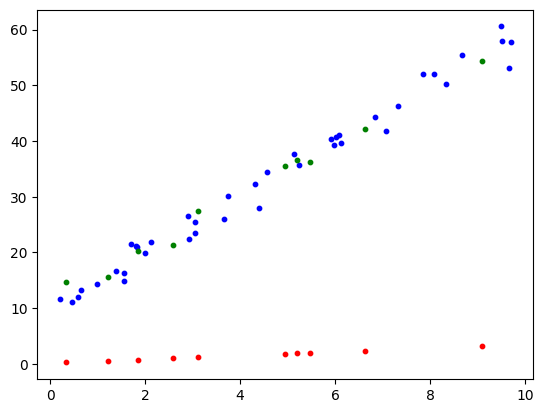

In [78]:
plt.scatter(x=X_train,y=y_train,c="b",s=10, label="Training Data") # s -> size of data points.
plt.scatter(x=X_test,y=y_test,c="g",s=10,label = "Test Data")
plt.scatter(x=X_test,y=y_pred,c="r",s=10,label="Prediction Data")
plt.show()
# Yeşiller doğru sonuçlar aslında kırmızılar predictionlarımız baya kötü durumdayız yani
# Çünkü eğitim yapmadık.

In [79]:
# Modeli eğitmek
# Modeli eğitirken hangi mimariyle çalışırsak çalışalım bir loss fonksiyonumuz ve optimizer'ımız olmalı
loss_fn = nn.MSELoss() # Mean squared error loss fonksiyonumuz olarak seçtik
optimizer = torch.optim.SGD(params=model_0.parameters(),lr=0.001)
# Optimizer olarak biraz ilkel olan SGD'yi seçtik, içine parametrelerimizi ve learning rate'i verdik.
torch.manual_seed(42)

epochs = 120
train_loss_values = [] # Daha sonra grafiklerini çizmek adına bu değerlerimizi listede tutuyoruz.
test_loss_values = []
epoch_count = []
for epoch in range(epochs):
    model_0.train() # modelimizi eğitmeden önce her zaman train modu belirtmeliyiz.

    y_pred =model_0(X_train)  # Önce bir tahmin yaptırıyoruz sonra loss functiona göre dönüt vereceğiz.

    loss = loss_fn(y_pred, y_train) # MSE loss ile hesaplayacağız.

    optimizer.zero_grad() # eski gradientlar'ı siliyoruz her epoch'ta
    loss.backward() # model parametrelerine göre türevlerini hesaplar
    optimizer.step() # model ağırlıklarını güncelliyoruz.
    # yukarıdaki 3 satırla optimizer'ı kullanarak back propagation yapıyoruz.

    # son olarakta eğitimi değerlendirmemiz lazım
    # her epoch'ta deniyourz ki modelin çıktısını kontrol edebilelim gelişiyor mu diye
    model_0.eval() # değerlendirme modunu açıyoruz
    with torch.inference_mode():
        test_pred = model_0(X_test)

        test_loss = loss_fn(test_pred,y_test) 
        # loss_fn(test_pred, y_test.type(torch.float)) şeklinde yazmak durumunda da kalabiliriz
        # type'lar uyuşmaz ise

        if epoch % 5 == 0: # Her 5 epoch'ta bir modelin sonuclarını görüntüleyelim
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy()) # matplotlib numpy ile çalıştığından yapıyoruz
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch}, Train Loss {loss}, Test Loss {test_loss}")

Epoch: 0, Train Loss 1156.0767463081781, Test Loss 858.3088765088272
Epoch: 5, Train Loss 633.9334744710083, Test Loss 484.2837829868178
Epoch: 10, Train Loss 352.99125276114285, Test Loss 280.90521005460033
Epoch: 15, Train Loss 201.80191856738534, Test Loss 169.8918797355706
Epoch: 20, Train Loss 120.41268871324436, Test Loss 108.98031233032034
Epoch: 25, Train Loss 76.57232180621143, Test Loss 75.32370882849361
Epoch: 30, Train Loss 52.931428428694815, Test Loss 56.55033419714631
Epoch: 35, Train Loss 40.157054153236494, Test Loss 45.9453113422317
Epoch: 40, Train Loss 33.22852214719357, Test Loss 39.85290344471839
Epoch: 45, Train Loss 29.44508410079029, Test Loss 36.274774134597365
Epoch: 50, Train Loss 27.353844189863754, Test Loss 34.11265188608324
Epoch: 55, Train Loss 26.173217192098285, Test Loss 32.75872353470674
Epoch: 60, Train Loss 25.482772613444595, Test Loss 31.87363984152036
Epoch: 65, Train Loss 25.05632900940991, Test Loss 31.26573939514797
Epoch: 70, Train Loss 24.

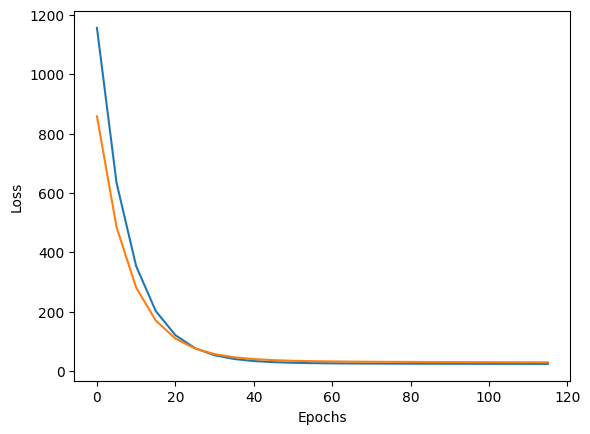

In [ ]:
plt.plot(epoch_count, train_loss_values, label="Train Loss")
plt.plot(epoch_count,test_loss_values, label = "Test Loss")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.show()
# Grafiği incelediğimizde istendiği gibi bir grafik elde ediyoruz. 60 epoch bile yeterli olabilirmiş.
# Smooth bir grafik var. istenen şekilde.

In [ ]:
model_0.state_dict()
# Burada da yani ax + b olarak düşünürsek 1 kişi 0 saat ders çalışırsa 1.6607 gibi bir not alacak.
# Örneğin x = 10 olursa 10 saat çalışırsa, 10*6.2983 + 1.6607 gibi bir not alacak.
# Güncel ağırlıklarımız bu şekilde yani.

OrderedDict([('weights', tensor([6.2983])), ('bias', tensor([1.6607]))])

In [82]:
model_0.eval()
with torch.inference_mode():
    y_preds = model_0(X_test)

In [83]:
X_test

tensor([1.2204, 4.9518, 0.3439, 9.0932, 2.5878, 6.6252, 3.1171, 5.2007, 5.4671,
        1.8485], dtype=torch.float64)

In [84]:
y_preds

tensor([ 9.3471, 32.8485,  3.8266, 58.9326, 17.9595, 43.3885, 21.2933, 34.4162,
        36.0943, 13.3034], dtype=torch.float64)

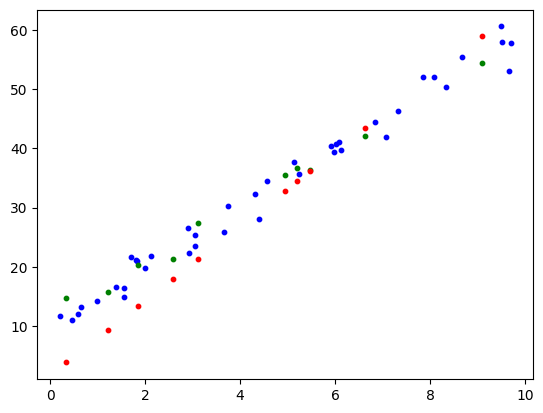

In [ ]:
plt.scatter(x=X_train,y=y_train,c="b",s=10, label="Training Data")
plt.scatter(x=X_test,y=y_test,c="g",s=10,label = "Test Data")
plt.scatter(x=X_test,y=y_preds,c="r",s=10,label="Predictions")
plt.show()
# Eğitimden sonra kırmızı olan tahminlerimiz yeşil olan gerçek sonuçlara daha yakın görüldüğü gibi
# loss_fn 'ı MAE yapabiliriz (Mean absoulute error) vs vs. Learning rate'i değiştirebiliriz.
# parametrelerle oynanabilir.